# Partial Charge Probe

Split from the original combined "Attention Weights, Embeddings & Partial Charge Probe" notebook — this half covers the partial charge probe only. See `embedding_analysis.ipynb` (moved alongside this notebook into `notebooks/`) for embedding/attention analysis.

## Why Probe?

A model can achieve reasonable ESP prediction by learning surface-level correlations without encoding meaningful chemistry. This probe checks whether the atom embeddings after Stage 1 message passing carry semantically meaningful representations: if a frozen-backbone probe can recover per-atom partial charges (which directly determine ESP) with high R², the model has implicitly learned the charge distribution required for ESP prediction.

- Train a frozen-backbone MLP to predict per-atom partial charges from PQR files — one probe per model, so the two full-dataset champions can be compared directly.
- Probe is trained on embeddings extracted at `after_mp` (after Stage 1 bond → radial message passing) or `after_encoder` (raw element + residue + bond-count embeddings, before any message passing).
- High R² at `after_mp` — with backbone frozen — means the bond and radial message passing rounds are enriching atom representations with local chemical context, not just the encoder lookup.
- Section 2b breaks accuracy down by the atom's own observed PARSE charge class (not a hand-picked category list) to identify which chemical roles the embeddings distinguish well and which are conflated.

## Key Findings

See cell outputs below for the current run against both full-dataset champions.

> **Models & methodology:** `PROBE_MODELS` covers both full-dataset champions — `checkpoints/full_dataset/attention_aa4_aq2_qq16` and `checkpoints/full_dataset/distance_aa8_aq2_qq24` (re-pointed from the earlier single pre-staged-ablation checkpoint, `attention_both_batching`). Section 2b's per-environment breakdown now classifies atoms by their own **observed** PARSE charge value (see `src.analysis.charge_probe.load_parse_charge_reference`, which parses PDB2PQR's actual PARSE.DAT) instead of a hand-picked ~16-category list, so carbon (and every other element) shows its full real spread of chemically distinct charge classes rather than being lumped into one "aliphatic C" bucket. Trained probes are cached under `/home/student/thesis/outputs/charge_probes/` (seeded, reproducible) — delete a `.pt` file there to force a retrain.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

Training and evaluation happen in `scripts/run_charge_probe.py` (not in this notebook) — a probe per model, precomputed frozen-backbone embeddings (not re-extracted every epoch), seeded/reproducible, with real-time progress on the terminal. This notebook only loads that script's cached artifacts under `PROBE_SAVE_DIR`. Run the script first (or re-run it with `--force` to retrain) if any of the existence checks below come back `False`.

In [2]:
PROBE_MODELS   = ["attention", "distance"]
PROBE_LAYER    = "after_mp"
PROBE_SAVE_DIR = Path("/home/student/thesis/outputs/charge_probes")

for name in PROBE_MODELS:
    for suffix in (f"probe_{PROBE_LAYER}.pt", "eval_summary.json", "charge_classes.csv", "scatter_sample.npz"):
        p = PROBE_SAVE_DIR / f"{name}_{suffix}"
        print(f"{p.name:<38} exists: {p.exists()}")

attention_probe_after_mp.pt            exists: True
attention_eval_summary.json            exists: True
attention_charge_classes.csv           exists: True
attention_scatter_sample.npz           exists: True
distance_probe_after_mp.pt             exists: True
distance_eval_summary.json             exists: True
distance_charge_classes.csv            exists: True
distance_scatter_sample.npz            exists: True


---
## 2. Partial Charge Probe

Trains a small MLP on top of **frozen** atom embeddings to predict per-atom partial charges from PQR files. No backbone weights are modified — any predictive power comes entirely from information already encoded in the frozen embeddings.

Partial charges are the direct source of ESP: the APBS solver computes ESP by treating each atom as a point charge at its partial charge value. If the frozen embeddings encode partial charges well, the model has implicitly learned the charge representation that determines the output it is being trained to predict.

Two extraction layers are available for comparison:

| Layer | Description |
|-------|-------------|
| `after_encoder` | Raw element + residue + bond-count embeddings — no message passing |
| `after_mp` | After Stage 1 bond → radial rounds — local chemical context incorporated |

A large R² gap between `after_encoder` and `after_mp` would show that Stage 1 message passing meaningfully enriches atom representations beyond the initial lookup.

The probe MLP has two linear stages (`hidden_dim → hidden_dim // 2 → 1`), trained with backbone frozen. See `scripts/run_charge_probe.py` for the training/evaluation logic — this cell just loads each model's cached global + per-protein results.

In [3]:
probe_results = {}
for name in PROBE_MODELS:
    with open(PROBE_SAVE_DIR / f"{name}_eval_summary.json") as f:
        probe_results[name] = json.load(f)
    g = probe_results[name]["global"]
    print(f"{name:<10} RMSE={g['rmse']:.4f}  MAE={g['mae']:.4f}  "
          f"Mean R²={g['mean_r2']:.4f}  proteins={g['n_proteins']}  atoms={g['n_atoms']:,}")

comparison = pd.DataFrame({
    name: {"RMSE": r["global"]["rmse"], "MAE": r["global"]["mae"],
           "Mean R²": r["global"]["mean_r2"], "N proteins": r["global"]["n_proteins"],
           "N atoms": r["global"]["n_atoms"]}
    for name, r in probe_results.items()
}).T
print("\nCross-model comparison — does one architecture's backbone encode charge better?")
pd.set_option("display.float_format", "{:.4f}".format)
display(comparison)

attention  RMSE=0.0110  MAE=0.0068  Mean R²=0.9987  proteins=848  atoms=5,563,272
distance   RMSE=0.0132  MAE=0.0079  Mean R²=0.9981  proteins=848  atoms=5,563,272

Cross-model comparison — does one architecture's backbone encode charge better?


,RMSE,MAE,Mean R²,N proteins,N atoms
attention,0.0110,0.0068,0.9987,848.0000,5563272.0000
distance,0.0132,0.0079,0.9981,848.0000,5563272.0000


In [4]:
for name, results in probe_results.items():
    pp = results["per_protein"]
    per_protein_df = pd.DataFrame([
        {"Protein": pid, "RMSE": v["rmse"], "MAE": v["mae"], "R²": v["r2"], "N atoms": v["n_atoms"]}
        for pid, v in pp.items()
    ]).sort_values("R²", ascending=False)
    print(f"\n{name} — best 10 proteins by R²:")
    display(per_protein_df.head(10))
    print(f"{name} — worst 10 proteins by R²:")
    display(per_protein_df.tail(10))


attention — best 10 proteins by R²:


,Protein,RMSE,MAE,R²,N atoms
232,AF-A0A7L8Y648-F1,0.0084,0.0057,0.9993,779
222,AF-P0C0X0-F1,0.0084,0.0059,0.9993,1098
233,AF-Q18184-F1,0.0082,0.0057,0.9992,1401
215,AF-P65042-F1,0.0086,0.0058,0.9992,1628
273,AF-P27342-F1,0.0089,0.0056,0.9992,2029
93,AF-Q59X49-F1,0.0098,0.0067,0.9992,2875
162,AF-P40023-F1,0.0084,0.0057,0.9992,2294
421,AF-P35807-F1,0.0084,0.0057,0.9992,939
357,AF-P01098-F1,0.0088,0.0062,0.9992,1432
242,AF-P86013-F1,0.0084,0.0058,0.9992,823


attention — worst 10 proteins by R²:


,Protein,RMSE,MAE,R²,N atoms
382,AF-P42855-F1,0.0145,0.0076,0.9975,1805
316,AF-A7H543-F1,0.0149,0.0078,0.9975,5674
389,AF-Q9L1E4-F1,0.0154,0.0081,0.9974,3095
7,AF-P0DKM5-F1,0.0163,0.0084,0.9972,1418
51,AF-P0DPK3-2-F1,0.0171,0.0086,0.9971,3560
345,AF-Q3ZC66-F1,0.0174,0.0081,0.9967,1575
119,AF-P0CG57-F1,0.0184,0.0090,0.9965,1768
328,AF-P83952-F1,0.0205,0.0098,0.9956,762
299,AF-P0C5F2-F1,0.0208,0.0101,0.9951,591
196,AF-C0HJD7-F1,0.0218,0.0092,0.9950,1093



distance — best 10 proteins by R²:


,Protein,RMSE,MAE,R²,N atoms
204,AF-Q63665-5-F1,0.0097,0.0066,0.9990,295
233,AF-Q18184-F1,0.0097,0.0068,0.9990,1401
106,AF-Q96M27-4-F1,0.0100,0.0068,0.9989,4411
421,AF-P35807-F1,0.0101,0.0066,0.9989,939
702,AF-P08489-F1,0.0114,0.0075,0.9989,12069
16,AF-Q15834-F1,0.0107,0.0071,0.9989,3073
846,AF-Q54IT1-F1,0.0115,0.0073,0.9988,12967
158,AF-O81836-F1,0.0107,0.0071,0.9988,4733
747,AF-P29555-F1,0.0110,0.0072,0.9988,8562
168,AF-P17839-F1,0.0109,0.0072,0.9988,4030


distance — worst 10 proteins by R²:


,Protein,RMSE,MAE,R²,N atoms
369,AF-P11478-F1,0.0190,0.0093,0.9961,1442
230,AF-Q86VX2-2-F1,0.0184,0.0079,0.9961,3171
19,AF-O49595-F1,0.0191,0.0100,0.9961,2800
294,AF-P82535-F1,0.0185,0.0082,0.9960,1174
196,AF-C0HJD7-F1,0.0196,0.0097,0.9960,1093
90,AF-P61950-F1,0.0190,0.0093,0.9959,2704
328,AF-P83952-F1,0.0209,0.0108,0.9955,762
345,AF-Q3ZC66-F1,0.0210,0.0096,0.9953,1575
119,AF-P0CG57-F1,0.0217,0.0102,0.9952,1768
299,AF-P0C5F2-F1,0.0231,0.0109,0.9939,591


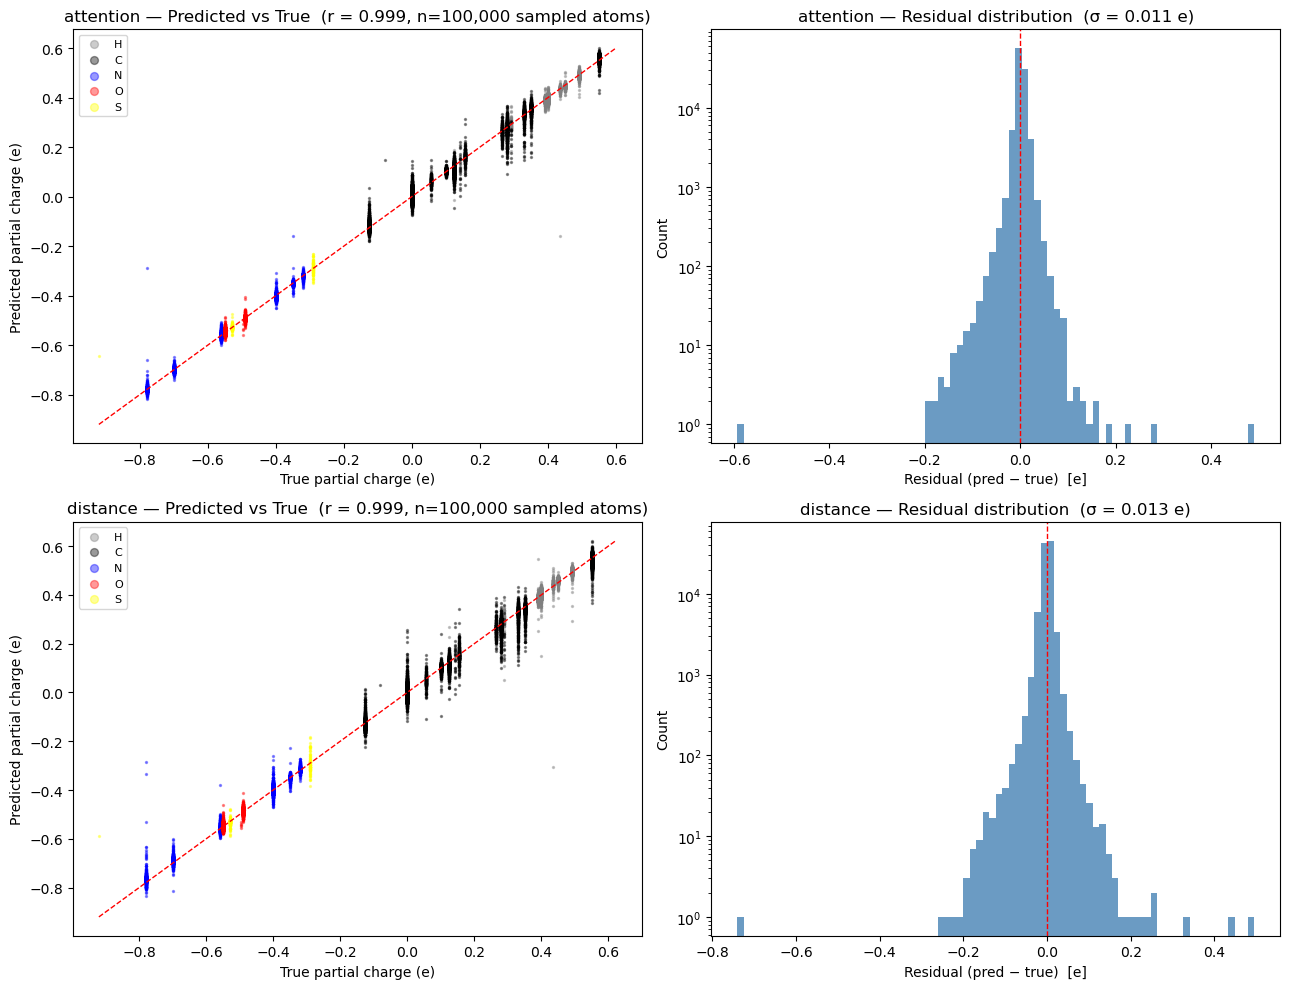

In [5]:
ELEMENT_NAME_BY_IDX = {0: "H", 1: "C", 2: "N", 3: "O", 4: "S", 5: "P", 6: "unknown"}
elem_colors = {0: "gray", 1: "black", 2: "blue", 3: "red", 4: "yellow", 5: "orange", 6: "purple"}

scatter_data = {}
for name in PROBE_MODELS:
    npz = np.load(PROBE_SAVE_DIR / f"{name}_scatter_sample.npz")
    scatter_data[name] = (npz["true_charge"], npz["pred_charge"], npz["element"])

fig, axes = plt.subplots(len(scatter_data), 2, figsize=(13, 5 * len(scatter_data)))
if len(scatter_data) == 1:
    axes = axes.reshape(1, -1)

for row, (name, (t, p, e)) in enumerate(scatter_data.items()):
    r = float(np.corrcoef(t, p)[0, 1])

    ax = axes[row, 0]
    for idx, ename in ELEMENT_NAME_BY_IDX.items():
        mask = e == idx
        if mask.any():
            ax.scatter(t[mask], p[mask], s=2, alpha=0.4, color=elem_colors.get(idx, "gray"),
                       label=ename, rasterized=True)
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_xlabel("True partial charge (e)")
    ax.set_ylabel("Predicted partial charge (e)")
    ax.set_title(f"{name} — Predicted vs True  (r = {r:.3f}, n={len(t):,} sampled atoms)")
    ax.legend(loc="upper left", fontsize=8, markerscale=4)

    ax = axes[row, 1]
    residuals = p - t
    ax.hist(residuals, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    ax.axvline(0, color="red", linewidth=1, linestyle="--")
    ax.set_xlabel("Residual (pred − true)  [e]")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.set_title(f"{name} — Residual distribution  (σ = {residuals.std():.3f} e)")

plt.tight_layout()
plt.show()

### 2b. Per-Charge-Class Accuracy (PARSE-Grounded)

Groups atoms by their own **observed** ground-truth PARSE charge (rounded to 3 decimals — PARSE's own native precision) rather than a hand-picked semantic category. This recovers PARSE's full granularity directly: e.g. carbon alone spans on the order of a dozen-plus distinct charge values across standard residues (plain aliphatic CH2/CH3, backbone carbonyl, aromatic ring carbons, Lys/Glu/Gln side-chain carbons, etc.), not one undifferentiated "aliphatic C" bucket. Each class is auto-labeled via `load_parse_charge_reference()`'s `(resname, atomname) -> charge` dictionary (parsed directly from PDB2PQR's `PARSE.DAT`), listing a few representative PARSE entries that produce that exact charge.

**Why classify by observed charge instead of looking up `(res_name, atom_name)`:** PDB2PQR always writes the base residue name (e.g. `"HIS"`) in the output PQR regardless of which internal protonation-state tautomer (HIS/HID/HIE/HIP — each with different PARSE charges) it actually assigned at pH 7 — confirmed directly against this dataset's PQR files. A name-keyed lookup would therefore silently pick the wrong tautomer's charge for some atoms; the atom's own observed charge (already loaded from the PQR file, already exactly what the probe is trained to predict) is always correct regardless of which tautomer produced it.

**Note on NaN correlations:** classes with zero charge variance (PARSE assigns one fixed charge to every atom in that class) have undefined Pearson r — a low RMSE with NaN r means the probe is accurately predicting a constant, not failing.

In [6]:
env_tables = {}
for name in PROBE_MODELS:
    env_df = pd.read_csv(PROBE_SAVE_DIR / f"{name}_charge_classes.csv")
    env_tables[name] = env_df
    print(f"\n{name} — {len(env_df)} distinct (element, charge-class) groups, "
          f"{env_df['N atoms'].sum():,} atoms total:")
    pd.set_option("display.float_format", "{:.4f}".format)
    display(env_df)


attention — 36 distinct (element, charge-class) groups, 5,563,272 atoms total:


,Label,Element,Charge class,N atoms,Mean charge,Charge std,RMSE,MAE,Pearson r
0,"C q=-0.125 (HID.CG, HIS.CD2, PHE.CD1...)",C,-0.1250,155891,-0.1250,0.0000,0.0168,0.0106,NaN
1,C q=-0.080 (CY-.CB),C,-0.0800,48,-0.0800,0.0000,0.1973,0.1929,NaN
2,"C q=+0.000 (ACE.CA, ACE.HA1, ACE.HA2...)",C,0.0000,982569,0.0000,0.0000,0.0125,0.0087,NaN
3,C q=+0.055 (TYR.CZ),C,0.0550,9910,0.0550,0.0000,0.0213,0.0159,NaN
4,"C q=+0.100 (ASP.CG, BK-.C, GLU.CD...)",C,0.1000,45836,0.1000,0.0000,0.0096,0.0073,NaN
5,"C q=+0.125 (HI+.CB, HI+.HD2, HI+.HE1...)",C,0.1250,34672,0.1250,0.0000,0.0345,0.0276,NaN
6,C q=+0.141 (HI+.CE1),C,0.1410,571,0.1410,0.0000,0.0461,0.0358,NaN
7,"C q=+0.142 (HI+.CD2, HI+.CG)",C,0.1420,1142,0.1420,0.0000,0.0573,0.0430,NaN
8,"C q=+0.155 (HID.CD2, HID.CE1, HIS.CE1...)",C,0.1550,15522,0.1550,0.0000,0.0287,0.0199,NaN
9,"C q=+0.265 (MET.CE, MET.CG)",C,0.2650,15860,0.2650,0.0000,0.0267,0.0197,NaN



distance — 36 distinct (element, charge-class) groups, 5,563,272 atoms total:


,Label,Element,Charge class,N atoms,Mean charge,Charge std,RMSE,MAE,Pearson r
0,"C q=-0.125 (HID.CG, HIS.CD2, PHE.CD1...)",C,-0.1250,155891,-0.1250,0.0000,0.0181,0.0127,NaN
1,C q=-0.080 (CY-.CB),C,-0.0800,48,-0.0800,0.0000,0.1082,0.0844,NaN
2,"C q=+0.000 (ACE.CA, ACE.HA1, ACE.HA2...)",C,0.0000,982569,0.0000,0.0000,0.0150,0.0110,NaN
3,C q=+0.055 (TYR.CZ),C,0.0550,9910,0.0550,0.0000,0.0284,0.0209,NaN
4,"C q=+0.100 (ASP.CG, BK-.C, GLU.CD...)",C,0.1000,45836,0.1000,0.0000,0.0146,0.0099,NaN
5,"C q=+0.125 (HI+.CB, HI+.HD2, HI+.HE1...)",C,0.1250,34672,0.1250,0.0000,0.0299,0.0225,NaN
6,C q=+0.141 (HI+.CE1),C,0.1410,571,0.1410,0.0000,0.0395,0.0309,NaN
7,"C q=+0.142 (HI+.CD2, HI+.CG)",C,0.1420,1142,0.1420,0.0000,0.0675,0.0517,NaN
8,"C q=+0.155 (HID.CD2, HID.CE1, HIS.CE1...)",C,0.1550,15522,0.1550,0.0000,0.0351,0.0233,NaN
9,"C q=+0.265 (MET.CE, MET.CG)",C,0.2650,15860,0.2650,0.0000,0.0336,0.0241,NaN


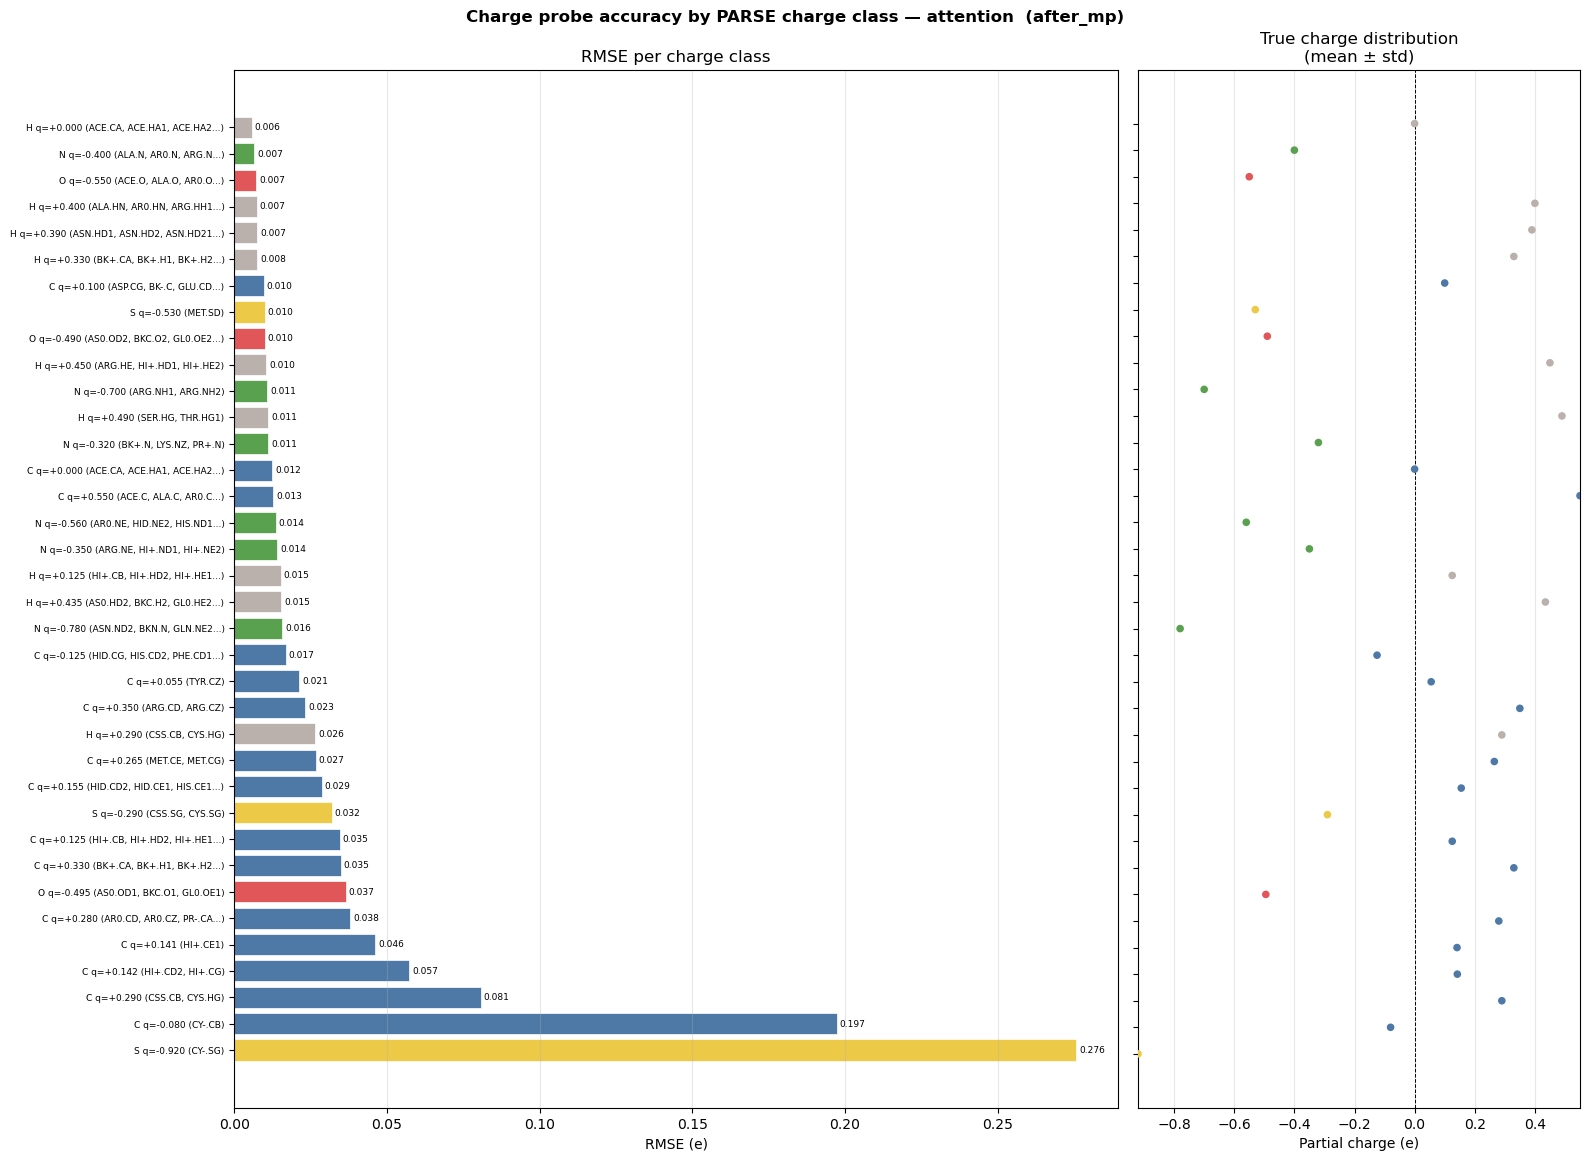

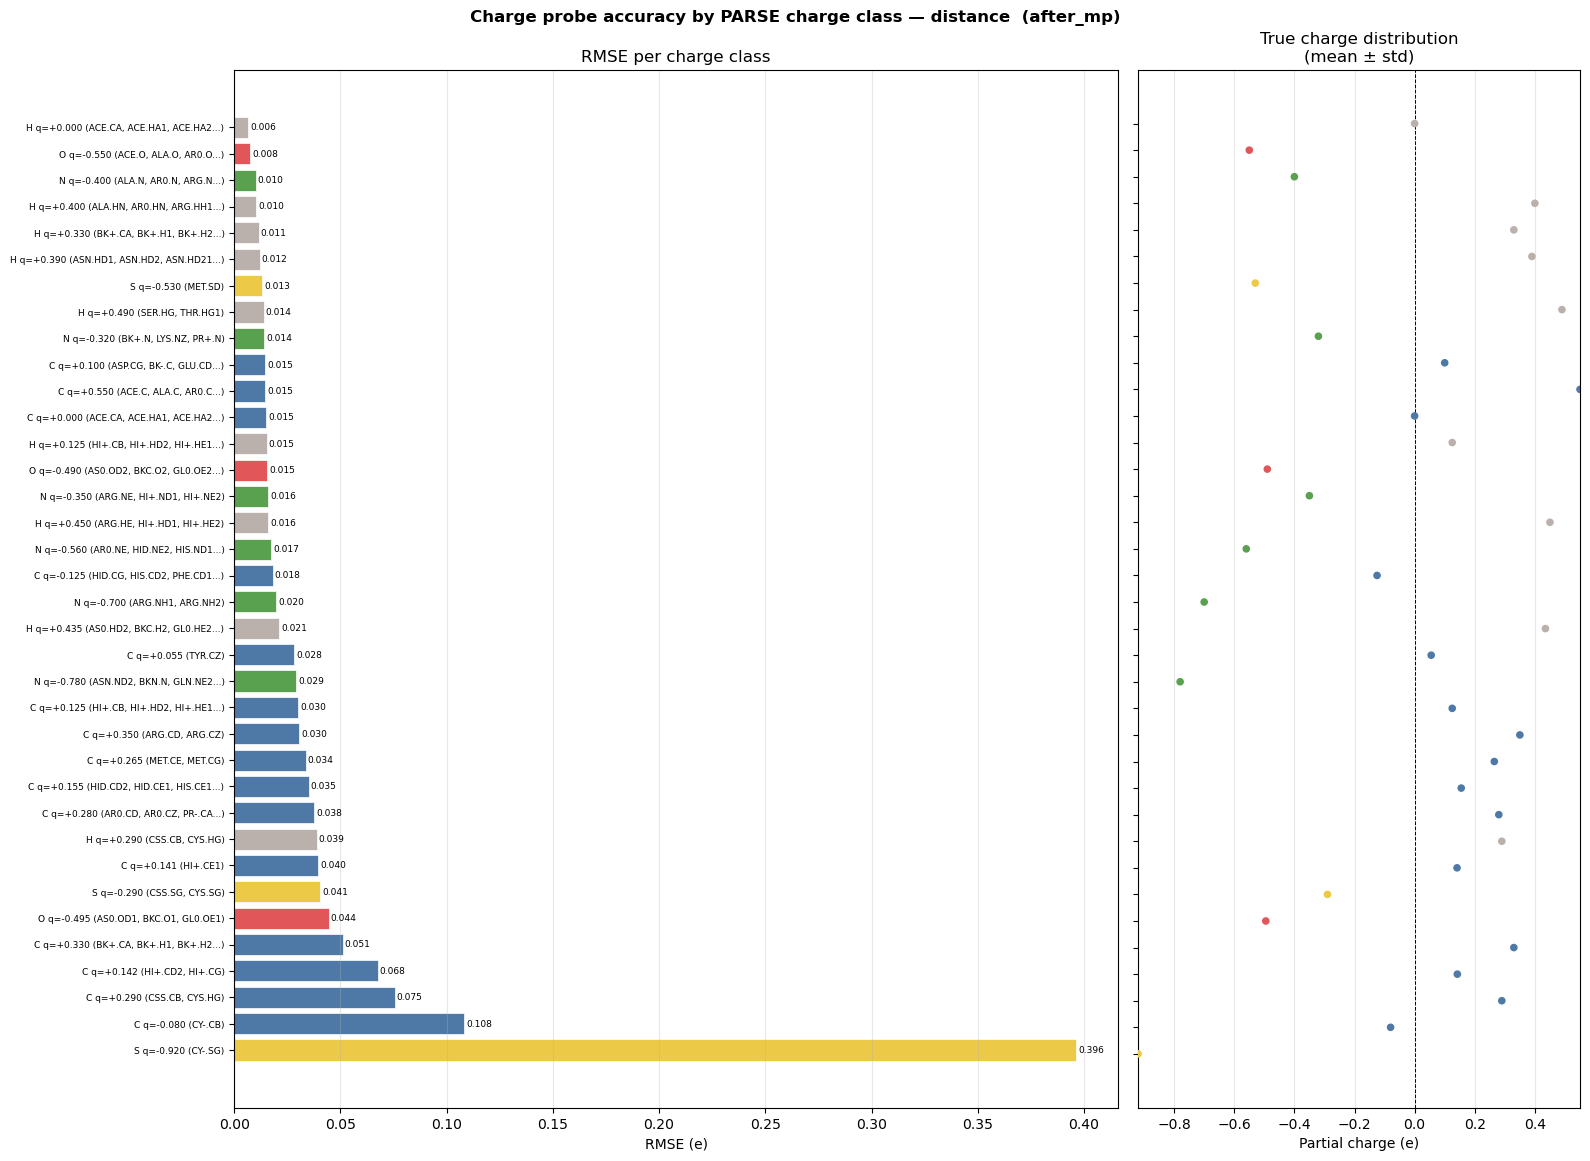

In [7]:
ELEMENT_COLORS = {
    "H": "#bab0ac", "C": "#4e79a7", "N": "#59a14f", "O": "#e15759",
    "S": "#edc948", "P": "#b07aa1", "unknown": "#9c755f",
}

for name, env_df in env_tables.items():
    plot_df = env_df[env_df["N atoms"] >= 20].sort_values("RMSE", ascending=False)
    colors_env = [ELEMENT_COLORS.get(e, "#9c755f") for e in plot_df["Element"]]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(plot_df) * 0.3 + 1)),
                             gridspec_kw={"width_ratios": [2, 1]})
    fig.suptitle(f"Charge probe accuracy by PARSE charge class — {name}  ({PROBE_LAYER})",
                 fontsize=12, fontweight="bold")

    y = np.arange(len(plot_df))

    ax = axes[0]
    bars = ax.barh(y, plot_df["RMSE"], color=colors_env, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Label"], fontsize=6.5)
    ax.set_xlabel("RMSE (e)")
    ax.set_title("RMSE per charge class")
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, plot_df["RMSE"]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=6.5)

    ax = axes[1]
    ax.barh(y, plot_df["Charge std"], left=plot_df["Mean charge"] - plot_df["Charge std"],
            height=0.5, color=colors_env, alpha=0.4, label="±1 std")
    ax.scatter(plot_df["Mean charge"], y, color=colors_env, s=20, zorder=3)
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels([], fontsize=9)
    ax.set_xlabel("Partial charge (e)")
    ax.set_title("True charge distribution\n(mean ± std)")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Notes & Observations

**Overall accuracy (full 848-protein test split, `after_mp` layer, 5,563,272 atoms):**

| Model | RMSE (e) | MAE (e) | Mean R² |
|---|---|---|---|
| attention | 0.0110 | 0.0068 | 0.9987 |
| distance | 0.0132 | 0.0079 | 0.9981 |

Both architectures recover per-atom PARSE partial charge almost perfectly from frozen, backbone-only embeddings — strong evidence that Stage 1 message passing encodes genuine local chemistry, not just a lookup of element identity. **Attention's backbone encodes charge measurably better** (16% lower RMSE, 14% lower MAE) — consistent with its cross-attention AQ stage giving it more capacity to sharpen chemically-relevant atom representations even before the query-facing stages are reached.

**Per-element RMSE** (both models agree on the ranking):

| Element | attention RMSE | distance RMSE |
|---|---|---|
| H | 0.0072 | 0.0086 |
| O | 0.0076 | 0.0088 |
| N | 0.0089 | 0.0140 |
| C | 0.0161 | 0.0186 |
| S | **0.0272** | **0.0364** |

Sulfur is hardest for both models by a wide margin — it's rare (only Cys/Met) and spans very different chemical roles (free thiol vs. disulfide-bonded), so the embeddings have the least data and the most within-element charge diversity to resolve. Carbon is the second hardest and — now that classification uses PARSE's real granularity instead of one "aliphatic C" bucket — clearly shows *why*: its 15 distinct observed charge classes range from RMSE 0.010 up to 0.057 (attention) / 0.068 (distance) within the element, the widest internal spread of any element. Backbone/common atoms (amide N, carbonyl O, aliphatic H) are the best-predicted classes overall — these are the highest-frequency, most context-invariant atoms in the dataset.

**Worst individual charge classes for both models**: histidine ring carbons in the protonated `HI+` tautomer state (`C q=+0.142`, `C q=+0.125`) and disulfide/thiol sulfur (`S q=-0.290`) — all relatively rare, chemically ambiguous environments, exactly where a name-keyed classifier would have been most likely to mis-assign the wrong tautomer's charge (motivating the observed-charge classification approach used here).

**`after_mp` vs. `after_encoder`**: this run only evaluated `after_mp` (`PROBE_LAYER = "after_mp"`, `scripts/run_charge_probe.py`'s default) — the encoder-only comparison from the original pre-staged-ablation notebook was not rerun at full-dataset scale. Revisiting that gap (rerun `run_charge_probe.py --layer after_encoder`) would be a natural follow-up if the encoder-vs-message-passing story is still needed for the writeup.
